In [7]:
# Computation of the expression analysis around plasmids contacts

In [8]:
#path="/mnt/c/Users/maely/Desktop/Thèse/E_histolytica_data/""
path="/media/sardine/data_2/Eukaroytic_plasmids_manual_research/E_histolytica_data"
hic_file = f"{path}/Entamoeba_histolytica.mcool"
fasta_file = f"{path}/E_histolytica.fna"
gff_file = f"{path}/genomic.gff"
rna_seq = f"{path}/E_histolytica.bw" # to find
plasmid = "AP023147.1"

In [56]:
import cooler
from BCBio import GFF
import pyBigWig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

def yield_genes_locs(gff):
    """Yields every gene location in the genomic gff provided."""
    for rec in GFF.parse(open(gff)):
        for feature in rec.features:
            if feature.type == "gene":
                yield rec.id, feature.location

def compute_contact(c, chrom, plasmid):
    d=c.info
    total_reads = d['sum']

    mat = c.matrix().fetch(chrom, plasmid)
    mat[np.isnan(mat)] = 0
    coverage_plasmid = mat.sum(axis=1)
    coverage_plasmid[coverage_plasmid==0] = np.nan

    matscn = c.matrix().fetch(chrom, chrom)
    matscn[np.isnan(matscn)] = 0
    coverage = matscn.sum(axis=0)
    coverage[coverage==0] = np.nan

    m1 = c.matrix(balance=False).fetch(chrom, chrom)
    reads_chrom= np.nansum(m1)
    m2 = c.matrix(balance=True).fetch(plasmid, plasmid)
    reads_plasmid= np.nansum(m2)
    m12 = c.matrix(balance=False).fetch(chrom, plasmid)
    reads_chr12= np.nansum(m12)

    coverage_plasmid = (coverage_plasmid/reads_chrom)/(reads_plasmid/reads_chr12)

    return coverage_plasmid

def get_loc_bin(cool, chromosome, loc):
    """Returns the first bin containing the coordinates in loc."""
    for b in cool.bins():
        if b.chrom != chromosome:
            continue
        

def get_gene_contact_by_size(cool, gff, plasmid, bw = None):
    """Associate each gene's length with its contact value with the plasmid ."""
    chromosomes_contact = {}
    chromosomes_tracks = {}
    gene_contact_by_size = []
    for chromosome, location in yield_genes_locs(gff):
        if chromosome not in chromosomes_contact:
            chromosomes_contact[chromosome] = compute_contact(cool, chromosome, plasmid)
            chromosomes_tracks[chromosome] = bw.stats(chromosome) or np.nan
        loc_bin = (location.start - 1) // cool.binsize
        gene_contact_by_size.append({
            "Gene size": location.end - location.start,
            "Contact with plasmid": chromosomes_contact[chromosome][loc_bin],
            "Tracks": bw.stats(chromosome, location.start, location.end)[0] or np.nan,
            "Average chromosomal track":chromosomes_tracks[chromosome][0]
        })
    return pd.DataFrame(gene_contact_by_size)

In [10]:
cool = cooler.Cooler(hic_file + "::resolutions/5000")
tracks = pyBigWig.open(rna_seq)
df_gene_contact_by_size = get_gene_contact_by_size(cool, gff_file, plasmid, bw = tracks)

/tmp/ipykernel_61082/3191149156.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  coverage_plasmid = (coverage_plasmid/reads_chrom)/(reads_plasmid/reads_chr12)
/tmp/ipykernel_61082/3191149156.py:37: RuntimeWarning: divide by zero encountered in divide
  coverage_plasmid = (coverage_plasmid/reads_chrom)/(reads_plasmid/reads_chr12)


In [23]:
df_gene_contact_by_size

,Gene size,Contact with plasmid,Tracks,Average chromosomal track
0,581,NaN,2.895241,12.295192
1,4068,NaN,2.924178,12.295192
2,690,0.012725,NaN,12.295192
3,657,0.017403,NaN,12.295192
4,639,0.003038,5.092075,12.295192
...,...,...,...,...
11482,2518,NaN,NaN,NaN
11483,1947,0.348892,51.339891,60.918825
11484,151,0.169608,44.902483,60.918825
11485,151,0.320116,NaN,60.918825


In [24]:
np.nanmax(df_gene_contact_by_size["Contact with plasmid"])

np.float64(inf)

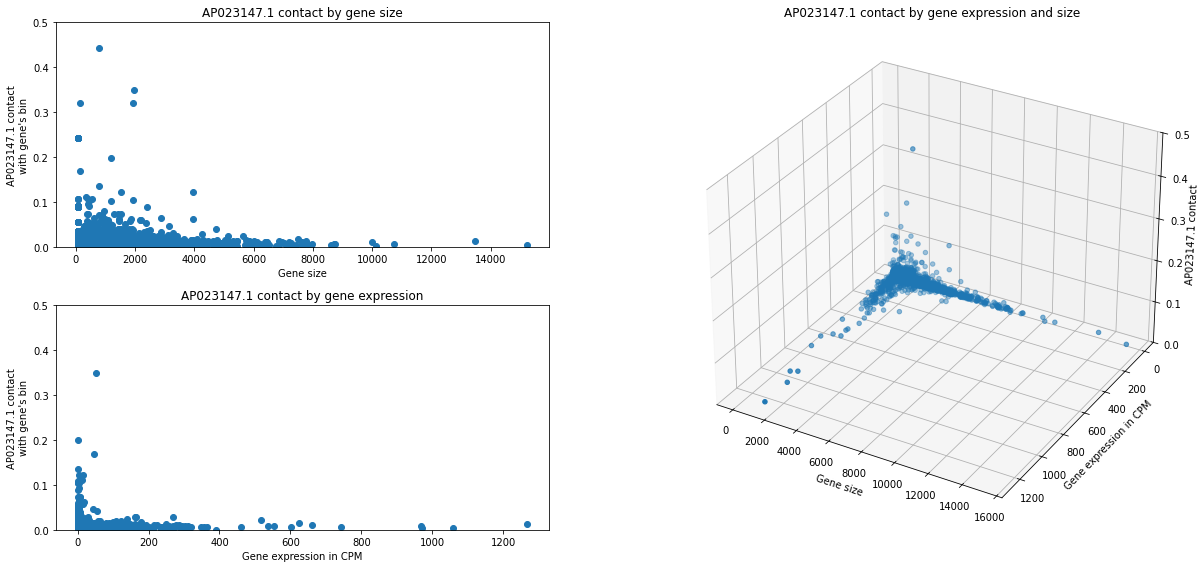

In [32]:
def plot_gene_stats(df_contact_size, outpath = "", contig_name = "plasmid"):
    """Plots the contents of df_gene_contact_by_size"""
    fig = plt.figure(figsize=(20, 8))

    gs = gridspec.GridSpec(
        nrows=2,
        ncols=2,
        width_ratios=[1, 2],   # right plot wider (optional)
        height_ratios=[1, 1],  # equal height left plots
    )

    ax1 = fig.add_subplot(gs[0, 0])   # top-left
    ax2 = fig.add_subplot(gs[1, 0])   # bottom-left
    ax3 = fig.add_subplot(gs[:, 1],projection='3d')   # right, spans both rows
    
    # Contact by gene size
    ax1.set_title(f"{contig_name} contact by gene size")
    ax1.scatter(df_contact_size["Gene size"], df_contact_size["Contact with plasmid"])
    ax1.set_ylim(0, 0.5)
    ax1.set_ylabel(f"{contig_name} contact\nwith gene's bin")
    ax1.set_xlabel("Gene size")
    
    # Contact by gene expression
    ax2.set_title(f"{contig_name} contact by gene expression")
    ax2.scatter(df_contact_size["Tracks"], df_contact_size["Contact with plasmid"])
    ax2.set_ylim(0, 0.5)
    ax2.set_ylabel(f"{contig_name} contact\nwith gene's bin")
    ax2.set_xlabel("Gene expression in CPM")
    
    # Contact by gene size and expression (pseudo-3D)
    np.random.seed(19680801)
    
    xlabel = "Gene size"
    ylabel = "Gene expression in CPM"
    zlabel = f"{contig_name} contact\nwith gene's bin"
    X, Y, Z = df_contact_size["Gene size"], df_contact_size["Tracks"], df_contact_size["Contact with plasmid"]

    ax3.set_title(f"{contig_name} contact by gene expression and size")
    ax3.scatter(X, Y, Z, marker='o')
    ax3.set_xlabel(xlabel)
    ax3.set_ylabel(ylabel)
    ymin, ymax = ax3.get_ylim()
    ax3.set_ylim(ymax, ymin)
    ax3.set_zlim(0, 0.5)
    ax3.set_zlabel(zlabel)
    
    plt.tight_layout()
    
    if len(outpath) > 0:
        plt.savefig(f'{outpath}/{contig_name}_contact_by_gene_size_and_exp.pdf', bbox_inches='tight')
        plt.savefig(f'{outpath}/{contig_name}_contact_by_gene_size_and_exp.png', bbox_inches='tight')
    
plot_gene_stats(df_gene_contact_by_size, outpath = path, contig_name = plasmid)

/tmp/ipykernel_61082/3347903180.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  coverage_plasmid = (coverage_plasmid/reads_chrom)/(reads_plasmid/reads_chr12)
/tmp/ipykernel_61082/3347903180.py:40: RuntimeWarning: divide by zero encountered in divide
  coverage_plasmid = (coverage_plasmid/reads_chrom)/(reads_plasmid/reads_chr12)
/tmp/ipykernel_61082/831572682.py:50: RuntimeWarning: All-NaN slice encountered
  binned_values.append(np.nanmedian(values[i:i+ binning]))


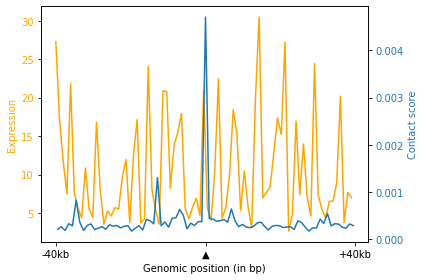

In [76]:
def get_quantile(bw, quantile, binning = 1000):
    """Returns the value of the required quantile from binned tracks values."""
    bw_values = []
    for chrom in bw.chroms():
        for i in range(0, bw.chroms(chrom), binning):
            end = i + binning if i + binning < bw.chroms(chrom) else bw.chroms(chrom)
            bw_values.append(bw.stats(chrom, i, end)[0] or np.nan)
            
    return np.nanquantile(bw_values, quantile)

def get_positions_from_tracks(bw, quantile, binning = 1000, values_range = "above"):
    """Computes the positions in bw where the value is above (or bellow depending on values_range) the required quantile."""
    
    positions = []
    quantile_value = get_quantile(bw, quantile, binning = binning)
    
    for chrom in bw.chroms():
        for i in range(0, bw.chroms(chrom), binning):
            end = i + binning if i + binning < bw.chroms(chrom) else bw.chroms(chrom)
            tmp_value = bw.stats(chrom, i, end)[0] or np.nan
            if (values_range == "above" and tmp_value >= quantile_value) or (values_range == "bellow" and tmp_value <= quantile_value):
                positions.append({
                    "Chromosome":chrom,
                    "Start":i,
                    "End":i + binning,
                    "Value":tmp_value
                })
    return pd.DataFrame(positions)

def extract_windows_from_tracks(bw, chrom, start, end, window, binning):
    """Returns the extracted window around the provided position from tracks. Fills missing value with nans."""
    # computing coordinates
    window_start = start - window//2
    window_end = end + window//2
    window_start_adjusted = window_start if window_start >= 0 else 0
    window_end_adjusted = window_end if window_end < bw.chroms(chrom) else bw.chroms(chrom)
    
    # extracting
    values = bw.values(chrom, window_start_adjusted, window_end_adjusted)
    
    # adjusting if missing values
    if window_start < 0:
        values = np.concatenate([[np.nan]*abs(window_start), values])
    if window_end >= bw.chroms(chrom):
        values = np.concatenate([values, [np.nan]*(abs(window_end - bw.chroms(chrom)))])
    
    binned_values = []
    for i in range(0, len(values), binning):
        end = i + binning if i + binning < len(values) else len(values)
        binned_values.append(np.nanmedian(values[i:i+ binning]))
        
    return binned_values

def extract_windows_from_contact(chromosome_contact, start, end, binning, window):
    """Returns the extracted window around the provided position from tracks. Fills missing value with nans."""
    # computing coordinates
    window_start = (start - window//2) // binning
    window_end = (end + window//2) // binning
    window_start_adjusted = window_start if window_start >= 0 else 0
    window_end_adjusted = window_end if window_end < len(chromosome_contact) else len(chromosome_contact)
    
    # extracting
    values = chromosome_contact[window_start_adjusted:window_end_adjusted]
    
    # adjusting if missing values
    if window_start < 0:
        values = np.concatenate([[np.nan]*abs(window_start), values])
    if window_end >= len(chromosome_contact):
        values = np.concatenate([values, [np.nan]*(abs(window_end - len(chromosome_contact)))])
        
    return values

def plot_exp_contact_pileup(tracks_pileup, contact_pileup, binning, window):
    """Plots the pileups on separate y axis."""
    fig = plt.figure(figsize=(6, 4))
    ax_tracks = fig.gca()
    
    color = 'orange'
    ax_tracks.set_xlabel('Genomic position (in bp)')
    ax_tracks.set_ylabel('Expression', color=color)
    tracks_index = [i for i in range(0, len(tracks_pileup) * binning, binning)]
    ax_tracks.plot(tracks_index, tracks_pileup, color=color)
    ax_tracks.tick_params(axis='y', labelcolor=color)
    
    ax_contact = ax_tracks.twinx()
    contact_index = [i + binning // 2 for i in range(0, len(contact_pileup) * binning, binning)]
    color = 'tab:blue'
    ax_contact.set_ylabel('Contact score', color=color)
    ax_contact.plot(contact_index, contact_pileup, color=color)
    ax_contact.tick_params(axis='y', labelcolor=color)
    
    ticks_index = [0, (0.5 * binning) + window // 2, binning + window]
    ticks_values = [f"-{window // (2* 1000)}kb", "▲", f"+{window // (2* 1000)}kb"]
    ax_tracks.set_xticks(ticks_index)
    ax_tracks.set_xticklabels(ticks_values)

    fig.tight_layout()
    plt.show()
    
def contact_from_exp_pileup(cool, tracks, plasmid, window = 50000, quantile = 0.95, values_range = "above"):
    """Computes positions from tracks where the value is above (or bellow depending on values_range) the selected quantile.
    Extracts a window around each position from the tracks and from the computed contact, and aggregate them separately.
    Plots the resulting pileups."""
    
    positions = get_positions_from_tracks(tracks, quantile, binning = cool.binsize)
    tracks_windows = [
        extract_windows_from_tracks(tracks, position["Chromosome"], position["Start"], position["End"], window, cool.binsize)
        for _, position in positions.iterrows()
    ]
    contact_windows = []
    chromosomes_contact = {}
    for _, position in positions.iterrows():
        chromosome = position["Chromosome"]
        if chromosome not in chromosomes_contact:
            chromosomes_contact[chromosome] = compute_contact(cool, chromosome, plasmid)
        extracted_window = extract_windows_from_contact(chromosomes_contact[chromosome], position["Start"], position["End"], cool.binsize, window)
        contact_windows.append(extracted_window)
    
    tracks_pileup = np.nanmean(tracks_windows, axis = 0)
    contact_pileup = np.nanmean(contact_windows, axis = 0)
    
    plot_exp_contact_pileup(tracks_pileup, contact_pileup, cool.binsize, window)
    
    return tracks_pileup, contact_pileup

def get_positions_from_contacts(cool, plasmid, min_heigth = 0.0025):
    """Computes the positions of the peaks in the plasmid contact in each chromosome."""
    
    # computing contacts
    chromosomes_contact = {chrom : compute_contact(cool, chrom, plasmid) for chrom in cool.chromnames if chrom != plasmid}
            
    # creating a single signal from which to extract the peaks
    signal = []
    indexes = []
    chromosomes_coordinates = {}
    shifts = {}
    global_shift = 0
    for chrom in chromosomes_contact.keys():
        chrom_signal = chromosomes_contact[chrom]
        shifts[chrom] = global_shift
        chrom_len = len(chrom_signal)
        index = range(shifts[chrom], shifts[chrom]  + chrom_len)
        chromosomes_coordinates.update({i: chrom for i in index})
        global_shift += chrom_len
    
        signal += list(chrom_signal)
        indexes += index
    
    # calling find peaks (from Girard et al., 2025 : To detect contact peaks with the 2μ plasmid, we used the
    #find_peaks function of the scipy package (with the following
    #parameters: height = 0.8, distance = 2). Before detection, the contact
    #signal was interpolated using the interp1d function of the scipy
    #package.)
    
    # signal interpolation
    interp_func = interp1d(indexes, signal, kind='linear')
    index_interp = np.linspace(min(indexes), max(indexes), len(indexes) * 10)
    signal_interp = interp_func(index_interp)

    # peaks detection
    peaks, properties = find_peaks(
        signal_interp,
        height=0.0025,
        distance=2
    )
    peak_positions = index_interp[peaks]
    peak_heights = properties["peak_heights"]
    positions = []
    # computing positions to pileup
    for position, height in zip(peak_positions, peak_heights):
        position_ind = round(position)
        chromosome = chromosomes_coordinates[position_ind]
        positions.append({
            "Chromosome":chromosome,
            "Start":(position_ind - shifts[chromosome]) * cool.binsize,
            "End":(position_ind - shifts[chromosome] + 1) * cool.binsize,
            "Height":height
        })
        
    return pd.DataFrame(positions)

def exp_from_contact_pileup(cool, tracks, plasmid, window = 50000):#, quantile = 0.95, values_range = "above"):
    """Computes positions from contact with find_peaks.
    Extracts a window around each position from the tracks and from the computed contact, and aggregate them separately.
    Plots the resulting pileups."""
    
    positions = get_positions_from_contacts(cool, plasmid, min_heigth = 0.0025)
    tracks_windows = [
        extract_windows_from_tracks(tracks, position["Chromosome"], position["Start"], position["End"], window, cool.binsize)
        for _, position in positions.iterrows()
    ]
    contact_windows = []
    chromosomes_contact = {}
    for _, position in positions.iterrows():
        chromosome = position["Chromosome"]
        if chromosome not in chromosomes_contact:
            chromosomes_contact[chromosome] = compute_contact(cool, chromosome, plasmid)
        extracted_window = extract_windows_from_contact(chromosomes_contact[chromosome], position["Start"], position["End"], cool.binsize, window)
        contact_windows.append(extracted_window)
    
    tracks_pileup = np.nanmean(tracks_windows, axis = 0)
    contact_pileup = np.nanmean(contact_windows, axis = 0)
    
    plot_exp_contact_pileup(tracks_pileup, contact_pileup, cool.binsize, window)
    
    return tracks_pileup, contact_pileup

cool = cooler.Cooler(hic_file + "::resolutions/1000")
#tracks_pileup, contact_pileup = contact_from_exp_pileup(cool, tracks, plasmid, window = 80000, quantile = 0.05, values_range = "bellow")
tracks_pileup, contact_pileup = exp_from_contact_pileup(cool, tracks, plasmid, window = 80000)#, quantile = 0.05, values_range = "bellow")

/tmp/ipykernel_61082/831572682.py:50: RuntimeWarning: All-NaN slice encountered
  binned_values.append(np.nanmedian(values[i:i+ binning]))


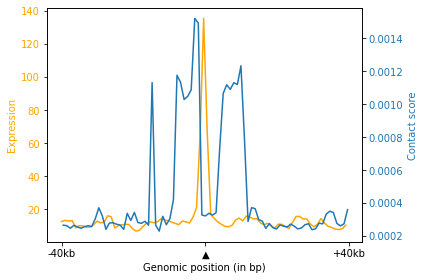

/tmp/ipykernel_61082/831572682.py:50: RuntimeWarning: All-NaN slice encountered
  binned_values.append(np.nanmedian(values[i:i+ binning]))


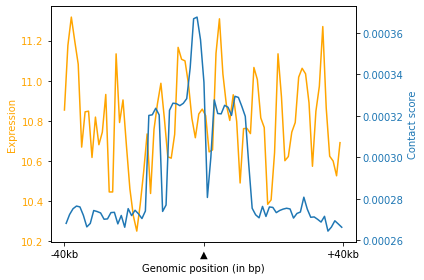

In [72]:
tracks_pileup, contact_pileup = contact_from_exp_pileup(cool, tracks, plasmid, window = 80000, quantile = 0.95, values_range = "above")
tracks_pileup, contact_pileup = contact_from_exp_pileup(cool, tracks, plasmid, window = 80000, quantile = 0.05, values_range = "bellow")

In [60]:
tracks_pileup, contact_pileup

(array([       nan,        nan,        nan, 2.21144009, 2.21144009,
        2.21144009, 2.21144009, 2.21144009, 2.21144009]),
 array([       nan,        nan,        nan,        nan, 0.01915547,
        0.03010163, 0.02672137, 0.02227583, 0.02185103]))